In [30]:
# download ERA5
import cdsapi
import os
 
# ── Parameters ────────────────────────────────────────────────────────
# Region: Southern California coast
REGION = [38, -122, 32, -115]  # [North, West, South, East]
 
# Single day, hourly — realistic for cloud seeding planning
YEAR  = "2020"
MONTH = "01"
# DAYS  = ["01"]
# TIMES = [f"{h:02d}:00" for h in range(0, 24)]  # 24 hourly snapshots
DAYS  = [str(d).zfill(2) for d in range(1, 8)]  # Jan 1-7
TIMES = [f"{h:02d}:00" for h in range(0, 24)]    # still hourly hourly
 
# 850hPa pressure level — cloud seeding altitude
VARIABLES = [
    "u_component_of_wind",
    "v_component_of_wind",
    "temperature",
    "geopotential",
]
PRESSURE_LEVEL = ["850"]
 
OUTPUT_FILE = "era5_socal.nc"
 
# ── Download ──────────────────────────────────────────────────────────
c = cdsapi.Client()
 
c.retrieve(
    "reanalysis-era5-pressure-levels",
    {
        "product_type": "reanalysis",
        "variable": VARIABLES,
        "pressure_level": PRESSURE_LEVEL,
        "year": YEAR,
        "month": MONTH,
        "day": DAYS,
        "time": TIMES,
        "area": REGION,
        "format": "netcdf",
    },
    OUTPUT_FILE,
)
 
print(f"Downloaded to {OUTPUT_FILE}")
print(f"File size: {os.path.getsize(OUTPUT_FILE) / 1e6:.1f} MB")

2026-06-11 21:59:59,842 INFO [2026-06-11T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 15 June. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure-part-2/150414).
2026-06-11 22:00:00,348 INFO Request ID is 9fefb8ab-5afa-4b9f-ae84-9478335c93ec
2026-06-11 22:00:00,571 INFO status has been updated to accepted
2026-06-11 22:00:24,825 INFO status has been updated to running
2026-06-11 22:01:20,893 INFO status has been updated to successful
                                                                                        

Downloaded to era5_socal.nc
File size: 1.0 MB


In [31]:
# Preprocess
import numpy as np
import xarray as xr
from sklearn.preprocessing import StandardScaler

# ── Load ──────────────────────────────────────────────────────────────
ds = xr.open_dataset("era5_socal.nc")
print(ds)

lat = ds["latitude"].values
lon = ds["longitude"].values
times = ds["valid_time"].values  # 24 hourly timestamps
LAT, LON = np.meshgrid(lat, lon, indexing="ij")
n_grid = LAT.size
n_times = len(times)

print(f"Grid points: {n_grid}, Timestamps: {n_times}")

# ── Stack all timestamps ──────────────────────────────────────────────
all_rows = []
for t in range(n_times):
    u   = ds["u"].isel(valid_time=t, pressure_level=0).values.ravel()
    v   = ds["v"].isel(valid_time=t, pressure_level=0).values.ravel()
    tmp = ds["t"].isel(valid_time=t, pressure_level=0).values.ravel()
    z   = ds["z"].isel(valid_time=t, pressure_level=0).values.ravel()

    # Time features
    hour       = t  # 0-23
    hour_sin   = np.sin(2 * np.pi * hour / 24)
    hour_cos   = np.cos(2 * np.pi * hour / 24)
    hour_norm  = hour / 23.0  # normalized 0-1 for GP

    lat_flat = LAT.ravel()
    lon_flat = LON.ravel()

    for i in range(n_grid):
        all_rows.append([
            lat_flat[i], lon_flat[i],   # spatial location
            tmp[i], z[i],               # meteorological features
            hour_sin, hour_cos,         # cyclic time features for GBT
            hour_norm,                  # normalized time for GP
            u[i], v[i],                 # targets
            t,                          # timestamp index
        ])

data = np.array(all_rows)
# Columns: lat, lon, tmp, z, hour_sin, hour_cos, hour_norm, u, v, t_idx

# ── Station / held-out split (by location, consistent across time) ────
np.random.seed(42)
n_stations  = 100
station_idx = np.random.choice(n_grid, n_stations, replace=False)
held_out_idx = np.array([i for i in range(n_grid) if i not in station_idx])

# Split rows by whether their grid index is a station
grid_indices = data[:, 0] * 0  # placeholder
# Rebuild with grid index
all_rows_with_gidx = []
for t in range(n_times):
    for i in range(n_grid):
        all_rows_with_gidx.append(i)
grid_idx_col = np.array(all_rows_with_gidx)

station_mask   = np.isin(grid_idx_col, station_idx)
held_out_mask  = ~station_mask

train_data = data[station_mask]
test_data  = data[held_out_mask]

# Features for GBT: lat, lon, tmp, z, hour_sin, hour_cos
X_train_gbt = train_data[:, :6]
X_test_gbt  = test_data[:, :6]
y_u_train   = train_data[:, 7]
y_v_train   = train_data[:, 8]
y_u_test    = test_data[:, 7]
y_v_test    = test_data[:, 8]

# Inputs for GP: lat, lon, hour_norm (spatiotemporal)
X_train_gp  = train_data[:, [0, 1, 6]]
X_test_gp   = test_data[:, [0, 1, 6]]

# Scale GBT features
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_gbt)
X_test_scaled  = scaler.transform(X_test_gbt)

print(f"Training rows (stations x time): {len(train_data)}")
print(f"Held-out rows: {len(test_data)}")

# ── Save ──────────────────────────────────────────────────────────────
np.savez("preprocessed.npz",
    X_train_gbt=X_train_gbt, X_train_scaled=X_train_scaled,
    X_test_gbt=X_test_gbt,   X_test_scaled=X_test_scaled,
    X_train_gp=X_train_gp,   X_test_gp=X_test_gp,
    y_u_train=y_u_train, y_v_train=y_v_train,
    y_u_test=y_u_test,   y_v_test=y_v_test,
    station_idx=station_idx, held_out_idx=held_out_idx,
    lat=lat, lon=lon, n_times=n_times, n_grid=n_grid,
)
print("Saved to preprocessed.npz")

<xarray.Dataset> Size: 2MB
Dimensions:         (valid_time: 168, pressure_level: 1, latitude: 25,
                     longitude: 29)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 1kB 2020-01-01 ... 2020-01-07...
    expver          (valid_time) <U4 3kB ...
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 200B 38.0 37.75 37.5 ... 32.5 32.25 32.0
  * longitude       (longitude) float64 232B -122.0 -121.8 ... -115.2 -115.0
    number          int64 8B ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 487kB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 487kB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 487kB ...
    z               (valid_time, pressure_level, latitude, longitude) float32 487kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather

In [32]:
# GBT
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# ── Load ──────────────────────────────────────────────────────────────
data = np.load("preprocessed.npz")
X_train_scaled = data["X_train_scaled"]
X_test_scaled  = data["X_test_scaled"]
y_u_train      = data["y_u_train"]
y_v_train      = data["y_v_train"]
y_u_test       = data["y_u_test"]
y_v_test       = data["y_v_test"]

# ── Train ─────────────────────────────────────────────────────────────
gbt_u = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gbt_v = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)

gbt_u.fit(X_train_scaled, y_u_train)
gbt_v.fit(X_train_scaled, y_v_train)

# ── Predictions and residuals ─────────────────────────────────────────
u_pred_train = gbt_u.predict(X_train_scaled)
v_pred_train = gbt_v.predict(X_train_scaled)
resid_u_train = y_u_train - u_pred_train
resid_v_train = y_v_train - v_pred_train

u_pred_test = gbt_u.predict(X_test_scaled)
v_pred_test = gbt_v.predict(X_test_scaled)

# ── Evaluate ──────────────────────────────────────────────────────────
rmse_u = np.sqrt(mean_squared_error(y_u_test, u_pred_test))
rmse_v = np.sqrt(mean_squared_error(y_v_test, v_pred_test))
print(f"GBT RMSE-u: {rmse_u:.4f} m/s")
print(f"GBT RMSE-v: {rmse_v:.4f} m/s")

feature_names = ["lat", "lon", "temperature", "geopotential", "hour_sin", "hour_cos"]
print("\nFeature importances (u model):")
for name, imp in zip(feature_names, gbt_u.feature_importances_):
    print(f"  {name}: {imp:.3f}")

# ── Save ──────────────────────────────────────────────────────────────
np.savez("gbt_output.npz",
    u_pred_train=u_pred_train, v_pred_train=v_pred_train,
    u_pred_test=u_pred_test,   v_pred_test=v_pred_test,
    resid_u_train=resid_u_train, resid_v_train=resid_v_train,
)
print("\nSaved to gbt_output.npz")

GBT RMSE-u: 2.5867 m/s
GBT RMSE-v: 3.1607 m/s

Feature importances (u model):
  lat: 0.179
  lon: 0.118
  temperature: 0.190
  geopotential: 0.381
  hour_sin: 0.066
  hour_cos: 0.066

Saved to gbt_output.npz


In [47]:
# Baselines

import numpy as np
from sklearn.metrics import mean_squared_error

# ── Load data ─────────────────────────────────────────────────────────
pre = np.load("preprocessed.npz", allow_pickle=True)

y_u_train  = pre["y_u_train"]
y_v_train  = pre["y_v_train"]
y_u_test   = pre["y_u_test"]
y_v_test   = pre["y_v_test"]
X_test_gp  = pre["X_test_gp"]

# ── Subsample 5000 test points for evaluation ─────────────────────────
np.random.seed(42)
eval_idx = np.random.choice(len(y_u_test), 5000, replace=False)
y_u_eval = y_u_test[eval_idx]
y_v_eval = y_v_test[eval_idx]
X_eval   = X_test_gp[eval_idx]

# ── Baseline 1: Spatial Average ───────────────────────────────────────
u_avg = np.full(5000, np.mean(y_u_train))
v_avg = np.full(5000, np.mean(y_v_train))

rmse_u_avg = np.sqrt(mean_squared_error(y_u_eval, u_avg))
rmse_v_avg = np.sqrt(mean_squared_error(y_v_eval, v_avg))
print(f"Spatial Average — RMSE-u: {rmse_u_avg:.4f}  RMSE-v: {rmse_v_avg:.4f}")

# ── Baseline 2: Kriging ───────────────────────────────────────────────
try:
    from pykrige.ok import OrdinaryKriging

    # Kriging is purely spatial — use only first timestamp
    first_ts_mask = np.zeros(len(pre["X_train_gp"]), dtype=bool)
    first_ts_mask[:100] = True  # first 100 rows = first timestamp, 100 stations

    X_krig_train = pre["X_train_gp"][first_ts_mask]
    u_krig_train = y_u_train[first_ts_mask]
    v_krig_train = y_v_train[first_ts_mask]

    print("Fitting kriging models...")
    ok_u = OrdinaryKriging(
        X_krig_train[:, 1], X_krig_train[:, 0], u_krig_train,
        variogram_model="spherical", verbose=False, enable_plotting=False,
    )
    ok_v = OrdinaryKriging(
        X_krig_train[:, 1], X_krig_train[:, 0], v_krig_train,
        variogram_model="spherical", verbose=False, enable_plotting=False,
    )

    print("Predicting with kriging...")
    BATCH = 500
    u_krig_pred = np.zeros(5000)
    v_krig_pred = np.zeros(5000)

    for i in range(0, 5000, BATCH):
        batch = X_eval[i:i+BATCH]
        u_krig_pred[i:i+BATCH], _ = ok_u.execute("points", batch[:, 1], batch[:, 0])
        v_krig_pred[i:i+BATCH], _ = ok_v.execute("points", batch[:, 1], batch[:, 0])
        print(f"  Kriging progress: {min(i+BATCH, 5000)}/5000")

    rmse_u_krig = np.sqrt(mean_squared_error(y_u_eval, u_krig_pred))
    rmse_v_krig = np.sqrt(mean_squared_error(y_v_eval, v_krig_pred))
    print(f"Kriging          — RMSE-u: {rmse_u_krig:.4f}  RMSE-v: {rmse_v_krig:.4f}")

except ImportError:
    print("pykrige not installed — run: pip install pykrige")
    rmse_u_krig = np.nan
    rmse_v_krig = np.nan

# ── Summary ───────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Method':<25} {'RMSE-u':>10} {'RMSE-v':>10}")
print("="*55)
print(f"{'Spatial Average':<25} {rmse_u_avg:>10.4f} {rmse_v_avg:>10.4f}")
print(f"{'Kriging':<25} {rmse_u_krig:>10.4f} {rmse_v_krig:>10.4f}")
print("="*55)

# ── Save ──────────────────────────────────────────────────────────────
np.savez("baseline_output.npz",
    rmse_u_avg=rmse_u_avg,   rmse_v_avg=rmse_v_avg,
    rmse_u_krig=rmse_u_krig, rmse_v_krig=rmse_v_krig,
)
print("Saved to baseline_output.npz")

Spatial Average — RMSE-u: 3.3616  RMSE-v: 5.7225
Fitting kriging models...
Predicting with kriging...
  Kriging progress: 500/5000
  Kriging progress: 1000/5000
  Kriging progress: 1500/5000
  Kriging progress: 2000/5000
  Kriging progress: 2500/5000
  Kriging progress: 3000/5000
  Kriging progress: 3500/5000
  Kriging progress: 4000/5000
  Kriging progress: 4500/5000
  Kriging progress: 5000/5000
Kriging          — RMSE-u: 3.5562  RMSE-v: 5.7429

Method                        RMSE-u     RMSE-v
Spatial Average               3.3616     5.7225
Kriging                       3.5562     5.7429
Saved to baseline_output.npz


In [33]:
# GP
from scipy.optimize import minimize

# ── Load ──────────────────────────────────────────────────────────────
pre = np.load("preprocessed.npz")
gbt = np.load("gbt_output.npz")

X_train_gp    = pre["X_train_gp"]     # (100*24, 3) — lat, lon, time
X_test_gp     = pre["X_test_gp"]      # (625*24, 3)
resid_u_train = gbt["resid_u_train"]
resid_v_train = gbt["resid_v_train"]
u_pred_test   = gbt["u_pred_test"]
v_pred_test   = gbt["v_pred_test"]
y_u_test      = pre["y_u_test"]
y_v_test      = pre["y_v_test"]

# ── Subsample GP training points ──────────────────────────────────────
# Use every 6th timestamp to keep matrix tractable
# 100 stations x 4 timestamps = 400 training points → 800x800 matrix
np.random.seed(42)
n_train = len(X_train_gp)
# every_nth = 6
every_nth = 24 # over multiple days
gp_mask = np.zeros(n_train, dtype=bool)
gp_mask[::every_nth] = True

X_gp    = X_train_gp[gp_mask]
res_u   = resid_u_train[gp_mask]
res_v   = resid_v_train[gp_mask]
y_train = np.concatenate([res_u, res_v])
N       = len(X_gp)
M       = len(X_test_gp)

print(f"GP training points: {N} (stations x subsampled timestamps)")
print(f"GP test points: {M}")

# ── Spatiotemporal kernels ─────────────────────────────────────────────
# Input: (lat, lon, time_norm) — time_norm in [0,1]
# Spatial part uses first 2 dims, temporal part uses last dim

def spatial_rbf(X1, X2, ls=1.0, sigma=1.0):
    diff = X1[:, None, :2] - X2[None, :, :2]
    r2   = np.sum(diff**2, axis=-1)
    return sigma**2 * np.exp(-r2 / (2 * ls**2))

def temporal_rbf(X1, X2, lt=0.5):
    diff = X1[:, None, 2:] - X2[None, :, 2:]
    r2   = np.sum(diff**2, axis=-1)
    return np.exp(-r2 / (2 * lt**2))

def rbf_st_kernel(X1, X2, ls=1.0, lt=0.3, sigma=1.0):
    K_s = spatial_rbf(X1, X2, ls=ls, sigma=sigma)
    K_t = temporal_rbf(X1, X2, lt=lt)
    K   = K_s * K_t
    Z   = np.zeros_like(K)
    return np.block([[K, Z], [Z, K]])

def spatial_matern52(X1, X2, ls=1.0, sigma=1.0):
    diff = X1[:, None, :2] - X2[None, :, :2]
    r    = np.sqrt(np.sum(diff**2, axis=-1))
    r_l  = np.sqrt(5) * r / ls
    return sigma**2 * (1 + r_l + r_l**2 / 3) * np.exp(-r_l)

def matern52_st_kernel(X1, X2, ls=1.0, lt=0.3, sigma=1.0):
    K_s = spatial_matern52(X1, X2, ls=ls, sigma=sigma)
    K_t = temporal_rbf(X1, X2, lt=lt)
    K   = K_s * K_t
    Z   = np.zeros_like(K)
    return np.block([[K, Z], [Z, K]])

def spatial_divfree(X1, X2, ls=1.0, sigma=1.0):
    N    = len(X1)
    M    = len(X2)
    diff = X1[:, None, :2] - X2[None, :, :2]
    r2   = np.sum(diff**2, axis=-1)
    base = (sigma**2 / ls**2) * np.exp(-r2 / (2 * ls**2))
    outer = diff[:, :, :, None] * diff[:, :, None, :]
    outer = outer / ls**2
    I     = np.eye(2)[None, None, :, :]
    K_block = base[:, :, None, None] * (I - outer)
    K = np.zeros((2*N, 2*M))
    K[:N, :M] = K_block[:, :, 0, 0]
    K[:N, M:] = K_block[:, :, 0, 1]
    K[N:, :M] = K_block[:, :, 1, 0]
    K[N:, M:] = K_block[:, :, 1, 1]
    return K

def divfree_st_kernel(X1, X2, ls=1.0, lt=0.3, sigma=1.0):
    # Spatial divergence-free x temporal RBF
    N  = len(X1)
    M  = len(X2)
    K_s = spatial_divfree(X1, X2, ls=ls, sigma=sigma)  # (2N, 2M)
    K_t = temporal_rbf(X1, X2, lt=lt)                   # (N, M)
    # Kronecker-style: multiply each block by temporal correlation
    K_s[:N, :M] *= K_t
    K_s[:N, M:] *= K_t
    K_s[N:, :M] *= K_t
    K_s[N:, M:] *= K_t
    return K_s

KERNELS = {
    "RBF ST":             rbf_st_kernel,
    "Matern 5/2 ST":      matern52_st_kernel,
    "Divergence-Free ST": divfree_st_kernel,
}

# ── Marginal log likelihood ───────────────────────────────────────────
def neg_log_marginal_likelihood(params, kernel_fn, X, y):
    log_ls, log_lt, log_s, log_n = params
    ls = np.exp(log_ls)
    lt = np.exp(log_lt)
    s  = np.exp(log_s)
    n  = np.exp(log_n)
    K  = kernel_fn(X, X, ls=ls, lt=lt, sigma=s)
    K += n**2 * np.eye(len(K))
    K  = (K + K.T) / 2
    try:
        L     = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        log_det = 2 * np.sum(np.log(np.diag(L)))
        return 0.5 * y @ alpha + 0.5 * log_det + 0.5 * len(y) * np.log(2 * np.pi)
    except np.linalg.LinAlgError:
        return 1e10

BOUNDS_DEFAULT = [
    (np.log(0.5), np.log(3.0)),   # spatial length scale
    (np.log(0.1), np.log(0.9)),   # temporal length scale (fraction of day)
    (-2, 2),                       # sigma
    (-4, -0.5),                    # noise
]

BOUNDS_DIVFREE = [
    (np.log(0.5), np.log(5.0)),
    (np.log(0.1), np.log(0.9)),
    (-1, 3),
    (-3, 0),
]

# ── Run GP for each kernel ────────────────────────────────────────────
BATCH_SIZE = 50
results    = {}

for name, kernel_fn in KERNELS.items():
    print(f"\nOptimizing hyperparameters for {name} kernel...")

    bounds      = BOUNDS_DIVFREE if "Divergence" in name else BOUNDS_DEFAULT
    best_nll    = np.inf
    best_params = None

    for _ in range(5):
        x0 = np.array([np.random.uniform(*b) for b in bounds])
        res = minimize(
            neg_log_marginal_likelihood,
            x0,
            args=(kernel_fn, X_gp, y_train),
            method="L-BFGS-B",
            bounds=bounds,
        )
        if res.fun < best_nll:
            best_nll    = res.fun
            best_params = res.x

    ls_opt, lt_opt, s_opt, n_opt = np.exp(best_params)
    print(f"  ls: {ls_opt:.3f} deg  lt: {lt_opt:.3f}  sigma: {s_opt:.3f}  noise: {n_opt:.3f}")

    K_train = kernel_fn(X_gp, X_gp, ls=ls_opt, lt=lt_opt, sigma=s_opt)
    K_train += n_opt**2 * np.eye(2 * N)
    K_train  = (K_train + K_train.T) / 2

    L     = np.linalg.cholesky(K_train)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))

    n_batches  = int(np.ceil(M / BATCH_SIZE))
    gp_resid_u = np.zeros(M)
    gp_resid_v = np.zeros(M)
    gp_std_u   = np.zeros(M)
    gp_std_v   = np.zeros(M)

    for i in range(n_batches):
        start = i * BATCH_SIZE
        end   = min((i + 1) * BATCH_SIZE, M)
        batch = X_test_gp[start:end]
        B     = len(batch)

        K_star     = kernel_fn(X_gp, batch, ls=ls_opt, lt=lt_opt, sigma=s_opt)
        mu         = K_star.T @ alpha
        gp_resid_u[start:end] = mu[:B]
        gp_resid_v[start:end] = mu[B:]

        K_starstar = kernel_fn(batch, batch, ls=ls_opt, lt=lt_opt, sigma=s_opt)
        v          = np.linalg.solve(L, K_star)
        cov_post   = K_starstar - v.T @ v
        var_diag   = np.diag(cov_post)
        gp_std_u[start:end] = np.sqrt(np.maximum(var_diag[:B], 0))
        gp_std_v[start:end] = np.sqrt(np.maximum(var_diag[B:], 0))

    u_final = u_pred_test + gp_resid_u
    v_final = v_pred_test + gp_resid_v

    rmse_u     = np.sqrt(mean_squared_error(y_u_test, u_final))
    rmse_v     = np.sqrt(mean_squared_error(y_v_test, v_final))
    coverage_u = np.mean((y_u_test >= u_final - 1.96*gp_std_u) &
                         (y_u_test <= u_final + 1.96*gp_std_u))
    coverage_v = np.mean((y_v_test >= v_final - 1.96*gp_std_v) &
                         (y_v_test <= v_final + 1.96*gp_std_v))

    results[name] = {
        "rmse_u": rmse_u, "rmse_v": rmse_v,
        "coverage_u": coverage_u, "coverage_v": coverage_v,
        "u_final": u_final, "v_final": v_final,
        "gp_std_u": gp_std_u, "gp_std_v": gp_std_v,
    }

    print(f"  RMSE-u: {rmse_u:.4f}  RMSE-v: {rmse_v:.4f}")
    print(f"  Coverage-u: {coverage_u:.2%}  Coverage-v: {coverage_v:.2%}")

# ── Summary table ─────────────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'Method':<25} {'RMSE-u':>8} {'RMSE-v':>8} {'Cov-u':>8} {'Cov-v':>8}")
print("="*65)

rmse_u_gbt = np.sqrt(mean_squared_error(y_u_test, u_pred_test))
rmse_v_gbt = np.sqrt(mean_squared_error(y_v_test, v_pred_test))
print(f"{'GBT only':<25} {rmse_u_gbt:>8.4f} {rmse_v_gbt:>8.4f} {'N/A':>8} {'N/A':>8}")

for name, r in results.items():
    print(f"{'GBT + '+name:<25} {r['rmse_u']:>8.4f} {r['rmse_v']:>8.4f} "
          f"{r['coverage_u']:>8.2%} {r['coverage_v']:>8.2%}")
print("="*65)

# ── Save ──────────────────────────────────────────────────────────────
best = results["Divergence-Free ST"]
np.savez("gp_output.npz",
    u_final=best["u_final"], v_final=best["v_final"],
    gp_std_u=best["gp_std_u"], gp_std_v=best["gp_std_v"],
    rmse_u_rbf=results["RBF ST"]["rmse_u"],
    rmse_v_rbf=results["RBF ST"]["rmse_v"],
    rmse_u_mat=results["Matern 5/2 ST"]["rmse_u"],
    rmse_v_mat=results["Matern 5/2 ST"]["rmse_v"],
    rmse_u_div=results["Divergence-Free ST"]["rmse_u"],
    rmse_v_div=results["Divergence-Free ST"]["rmse_v"],
    rmse_u_gbt=rmse_u_gbt, rmse_v_gbt=rmse_v_gbt,
)
print("\nSaved best result to gp_output.npz")

GP training points: 700 (stations x subsampled timestamps)
GP test points: 105000

Optimizing hyperparameters for RBF ST kernel...
  ls: 0.799 deg  lt: 0.169  sigma: 2.450  noise: 0.607
  RMSE-u: 1.8096  RMSE-v: 2.1876
  Coverage-u: 90.75%  Coverage-v: 83.90%

Optimizing hyperparameters for Matern 5/2 ST kernel...
  ls: 0.999 deg  lt: 0.169  sigma: 2.429  noise: 0.607
  RMSE-u: 1.7319  RMSE-v: 2.1330
  Coverage-u: 91.49%  Coverage-v: 84.38%

Optimizing hyperparameters for Divergence-Free ST kernel...
  ls: 1.358 deg  lt: 0.211  sigma: 4.246  noise: 1.000
  RMSE-u: 2.2256  RMSE-v: 2.7114
  Coverage-u: 73.49%  Coverage-v: 68.10%

Method                      RMSE-u   RMSE-v    Cov-u    Cov-v
GBT only                    2.5867   3.1607      N/A      N/A
GBT + RBF ST                1.8096   2.1876   90.75%   83.90%
GBT + Matern 5/2 ST         1.7319   2.1330   91.49%   84.38%
GBT + Divergence-Free ST    2.2256   2.7114   73.49%   68.10%

Saved best result to gp_output.npz


/var/folders/lj/dkf5g3gd1gn4rs5_nrmhk4fr0000gn/T/ipykernel_15662/960539356.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


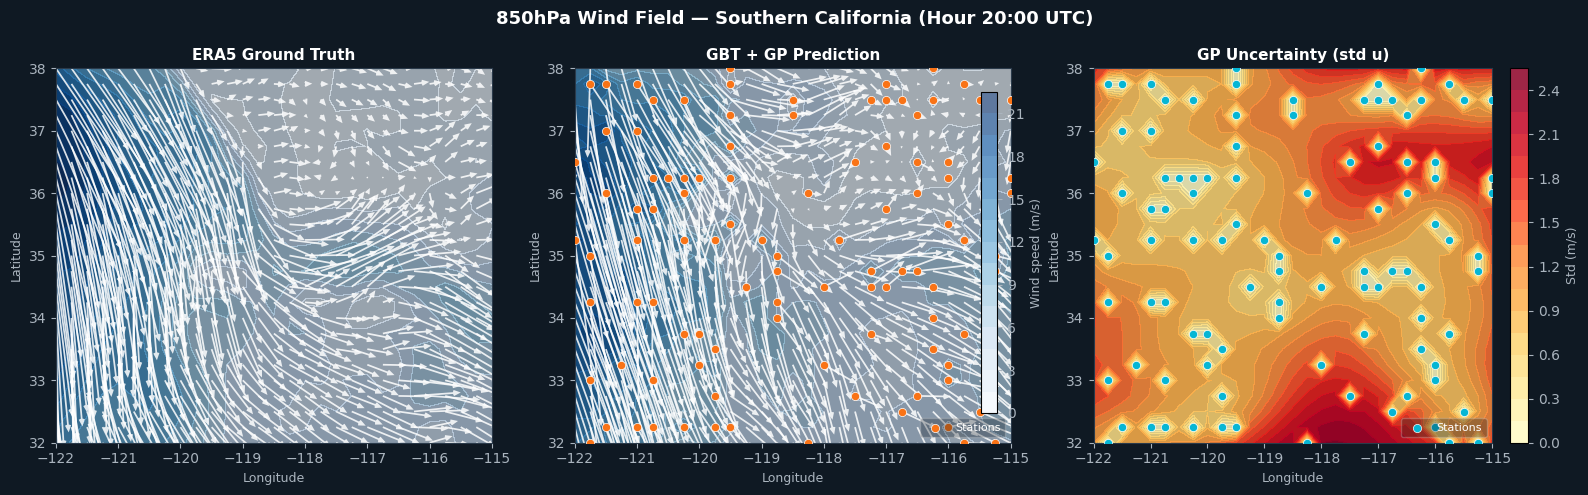

Saved quiver_plot.png


In [53]:
# quiver plot visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Load data ─────────────────────────────────────────────────────────
pre = np.load("preprocessed.npz", allow_pickle=True)
gbt = np.load("gbt_output.npz")
gp  = np.load("gp_output.npz")

lat         = pre["lat"]
lon         = pre["lon"]
n_times     = int(pre["n_times"])
n_grid      = int(pre["n_grid"])
station_idx = pre["station_idx"]
held_out_idx = pre["held_out_idx"]

# Full grid
LAT, LON = np.meshgrid(lat, lon, indexing="ij")

# ── Pick noon timestamp (hour=20) ─────────────────────────────────────
# Data is stacked as [grid_point_0_t0, grid_point_1_t0, ..., grid_point_0_t1, ...]
# Each timestamp block has n_grid rows
TARGET_HOUR = 20 # noon is 20 UTC, as this data is over southwest California

# Ground truth at all grid points at noon
y_u_full = pre["y_u_test"]  # held-out points, all timestamps
y_v_full = pre["y_v_test"]

# Slice out noon rows from test set
# test set has 625 locations x 24 timestamps
n_held = len(held_out_idx)
hour_start = TARGET_HOUR * n_held
hour_end   = hour_start + n_held

y_u_noon = y_u_full[hour_start:hour_end]
y_v_noon = y_v_full[hour_start:hour_end]

u_pred_noon = gp["u_final"][hour_start:hour_end]
v_pred_noon = gp["v_final"][hour_start:hour_end]
std_u_noon  = gp["gp_std_u"][hour_start:hour_end]
std_v_noon  = gp["gp_std_v"][hour_start:hour_end]

# ── Reconstruct full grid for plotting ────────────────────────────────
import xarray as xr
ds = xr.open_dataset("era5_socal.nc")
u_full_noon = ds["u"].isel(valid_time=TARGET_HOUR, pressure_level=0).values.ravel()
v_full_noon = ds["v"].isel(valid_time=TARGET_HOUR, pressure_level=0).values.ravel()
ds.close()

shape  = LAT.shape

# Ground truth — full grid
U_true = u_full_noon.reshape(shape)
V_true = v_full_noon.reshape(shape)

# Prediction — start from full ERA5, overwrite held-out points with GP prediction
u_pred_full = u_full_noon.copy()
v_pred_full = v_full_noon.copy()
u_pred_full[held_out_idx] = u_pred_noon
v_pred_full[held_out_idx] = v_pred_noon
U_pred = u_pred_full.reshape(shape)
V_pred = v_pred_full.reshape(shape)

# Uncertainty — zero at stations, GP std at held-out
std_full = np.zeros(n_grid)
std_full[held_out_idx] = std_u_noon
STD_U = std_full.reshape(shape)

# Station locations
sta_lon = LON.ravel()[station_idx]
sta_lat = LAT.ravel()[station_idx]

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#0f1923")
fig.suptitle(f"850hPa Wind Field — Southern California (Hour {TARGET_HOUR:02d}:00 UTC)",
             color="white", fontsize=13, fontweight="bold")

speed_true = np.sqrt(U_true**2 + V_true**2)
speed_pred = np.sqrt(U_pred**2 + V_pred**2)
vmin = np.nanmin([speed_true, speed_pred])
vmax = np.nanmax([speed_true, speed_pred])

qkw = dict(scale=60, width=0.004, headwidth=3.5, headlength=4)

# Panel 1 — Ground truth
ax = axes[0]
ax.set_facecolor("#0f1923")
cf = ax.contourf(LON, LAT, speed_true, levels=20, cmap="Blues", alpha=0.65, vmin=vmin, vmax=vmax)
ax.quiver(LON, LAT, U_true, V_true, color="white", alpha=0.85, **qkw)
ax.set_title("ERA5 Ground Truth", color="white", fontsize=11, fontweight="bold")

# Panel 2 — GP prediction
ax = axes[1]
ax.set_facecolor("#0f1923")
ax.contourf(LON, LAT, speed_pred, levels=20, cmap="Blues", alpha=0.65, vmin=vmin, vmax=vmax)
ax.quiver(LON, LAT, U_pred, V_pred, color="white", alpha=0.85, **qkw)
ax.scatter(sta_lon, sta_lat, color="#f97316", s=35, zorder=5,
           edgecolors="white", linewidths=0.5, label="Stations")
ax.legend(loc="lower right", fontsize=8, framealpha=0.3,
          labelcolor="white", facecolor="#0f1923")
ax.set_title("GBT + GP Prediction", color="white", fontsize=11, fontweight="bold")

# Panel 3 — Uncertainty
ax = axes[2]
ax.set_facecolor("#0f1923")
cf2 = ax.contourf(LON, LAT, STD_U, levels=20, cmap="YlOrRd", alpha=0.85)
ax.scatter(sta_lon, sta_lat, color="#06b6d4", s=35, zorder=5,
           edgecolors="white", linewidths=0.5, label="Stations")
ax.legend(loc="lower right", fontsize=8, framealpha=0.3,
          labelcolor="white", facecolor="#0f1923")
ax.set_title("GP Uncertainty (std u)", color="white", fontsize=11, fontweight="bold")
cbar2 = fig.colorbar(cf2, ax=ax, fraction=0.046, pad=0.04)
cbar2.set_label("Std (m/s)", color="#aab4be", fontsize=9)
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color="#aab4be")
cbar2.ax.yaxis.set_tick_params(color="#aab4be")

# Shared formatting
for ax in axes:
    ax.set_xlabel("Longitude", color="#aab4be", fontsize=9)
    ax.set_ylabel("Latitude",  color="#aab4be", fontsize=9)
    ax.tick_params(colors="#aab4be")
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a3a4a")

# Shared colorbar for panels 1 and 2
cbar = fig.colorbar(cf, ax=axes[:2], fraction=0.02, pad=0.02)
cbar.set_label("Wind speed (m/s)", color="#aab4be", fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#aab4be")
cbar.ax.yaxis.set_tick_params(color="#aab4be")

plt.tight_layout()
plt.savefig("quiver_plot.png", dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()
print("Saved quiver_plot.png")

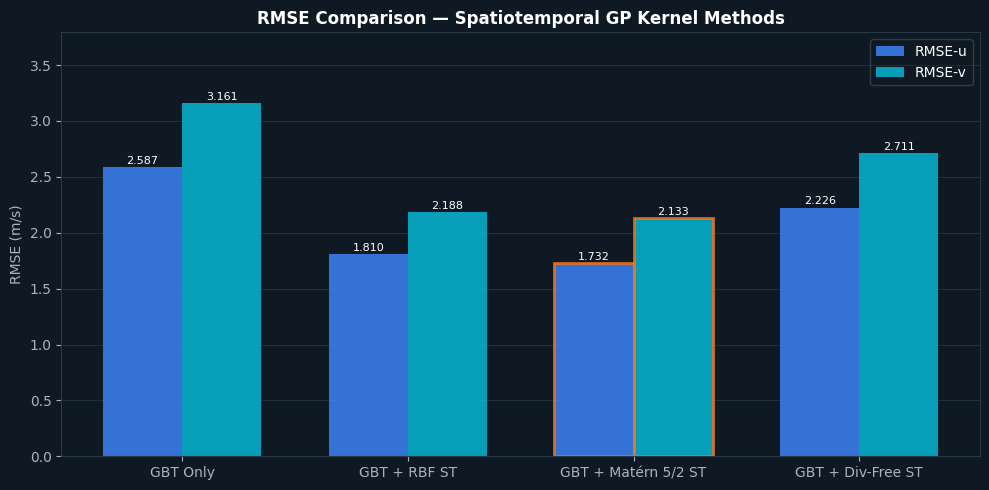

Saved rmse_plot.png


In [43]:
# RMSE charts
# ── Load real numbers from GP output ─────────────────────────────────
gp = np.load("gp_output.npz")
 
methods = ["GBT Only", "GBT + RBF ST", "GBT + Matérn 5/2 ST", "GBT + Div-Free ST"]
 
rmse_u = [
    float(gp["rmse_u_gbt"]),
    float(gp["rmse_u_rbf"]),
    float(gp["rmse_u_mat"]),
    float(gp["rmse_u_div"]),
]
rmse_v = [
    float(gp["rmse_v_gbt"]),
    float(gp["rmse_v_rbf"]),
    float(gp["rmse_v_mat"]),
    float(gp["rmse_v_div"]),
]
 
x     = np.arange(len(methods))
width = 0.35
 
fig, ax = plt.subplots(figsize=(10, 5), facecolor="#0f1923")
ax.set_facecolor("#0f1923")
 
bars_u = ax.bar(x - width/2, rmse_u, width, label="RMSE-u", color="#3b82f6", alpha=0.85)
bars_v = ax.bar(x + width/2, rmse_v, width, label="RMSE-v", color="#06b6d4", alpha=0.85)
 
# Highlight best method (Matern 5/2)
for bar in [bars_u[2], bars_v[2]]:
    bar.set_edgecolor("#f97316")
    bar.set_linewidth(2)
 
# Value labels
for bar in list(bars_u) + list(bars_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            color="white", fontsize=8)
 
ax.set_xticks(x)
ax.set_xticklabels(methods, color="white", fontsize=10)
ax.set_ylabel("RMSE (m/s)", color="#aab4be", fontsize=10)
ax.set_title("RMSE Comparison — Spatiotemporal GP Kernel Methods",
             color="white", fontsize=12, fontweight="bold")
ax.tick_params(colors="#aab4be")
ax.set_ylim(0, max(max(rmse_u), max(rmse_v)) * 1.2)
ax.yaxis.set_tick_params(color="#aab4be")
plt.setp(ax.yaxis.get_ticklabels(), color="#aab4be")
ax.legend(fontsize=10, framealpha=0.2, labelcolor="white", facecolor="#0f1923")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a3a4a")
ax.yaxis.grid(True, color="#2a3a4a", linewidth=0.5)
ax.set_axisbelow(True)
 
plt.tight_layout()
plt.savefig("rmse_plot.png", dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()
print("Saved rmse_plot.png")

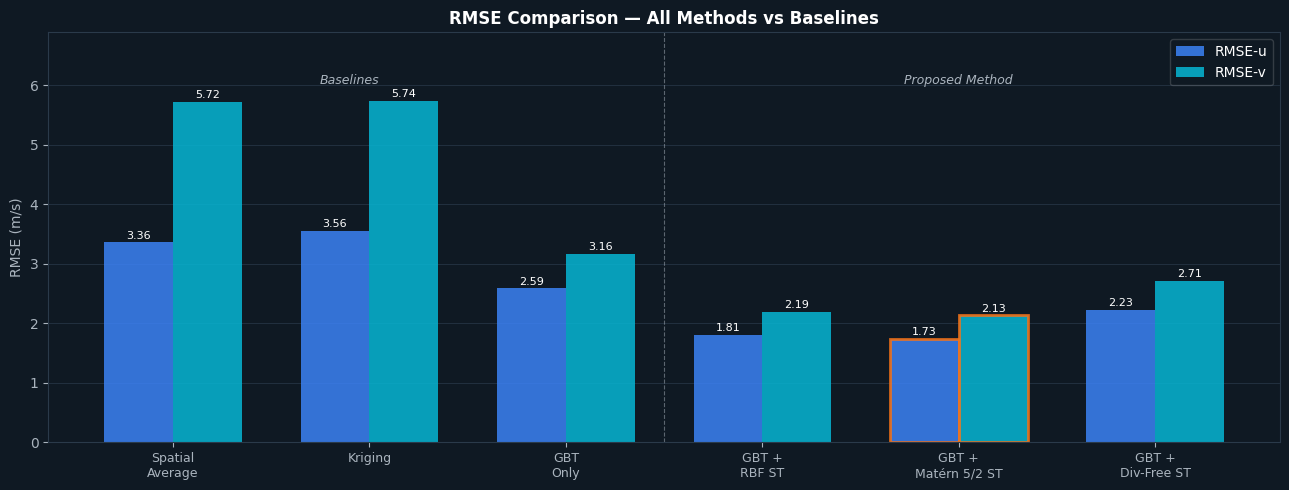

Saved rmse_plot.png


In [52]:
# combined charts with baselines

import numpy as np
import matplotlib.pyplot as plt

# ── Load real numbers ─────────────────────────────────────────────────
gp  = np.load("gp_output.npz")
bl  = np.load("baseline_output.npz")

methods = [
    "Spatial\nAverage",
    "Kriging",
    "GBT\nOnly",
    "GBT +\nRBF ST",
    "GBT +\nMatérn 5/2 ST",
    "GBT +\nDiv-Free ST",
]

rmse_u = [
    float(bl["rmse_u_avg"]),
    float(bl["rmse_u_krig"]),
    float(gp["rmse_u_gbt"]),
    float(gp["rmse_u_rbf"]),
    float(gp["rmse_u_mat"]),
    float(gp["rmse_u_div"]),
]
rmse_v = [
    float(bl["rmse_v_avg"]),
    float(bl["rmse_v_krig"]),
    float(gp["rmse_v_gbt"]),
    float(gp["rmse_v_rbf"]),
    float(gp["rmse_v_mat"]),
    float(gp["rmse_v_div"]),
]

x     = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5), facecolor="#0f1923")
ax.set_facecolor("#0f1923")

bars_u = ax.bar(x - width/2, rmse_u, width, label="RMSE-u", color="#3b82f6", alpha=0.85)
bars_v = ax.bar(x + width/2, rmse_v, width, label="RMSE-v", color="#06b6d4", alpha=0.85)

# Highlight best method — Matern 5/2
for bar in [bars_u[4], bars_v[4]]:
    bar.set_edgecolor("#f97316")
    bar.set_linewidth(2)

# Value labels
for bar in list(bars_u) + list(bars_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{bar.get_height():.2f}", ha="center", va="bottom",
            color="white", fontsize=8)

# Divider line between baselines and our methods
ax.axvline(x=2.5, color="#aab4be", linestyle="--", linewidth=0.8, alpha=0.5)
ax.text(0.9, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 6.5,
        "Baselines", color="#aab4be", fontsize=9, ha="center", style="italic")
ax.text(4.0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 6.5,
        "Proposed Method", color="#aab4be", fontsize=9, ha="center", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(methods, color="white", fontsize=9)
ax.set_ylabel("RMSE (m/s)", color="#aab4be", fontsize=10)
ax.set_title("RMSE Comparison — All Methods vs Baselines",
             color="white", fontsize=12, fontweight="bold")
ax.tick_params(colors="#aab4be")
ax.set_ylim(0, max(max(rmse_u), max(rmse_v)) * 1.2)
ax.yaxis.set_tick_params(color="#aab4be")
plt.setp(ax.yaxis.get_ticklabels(), color="#aab4be")
ax.legend(fontsize=10, framealpha=0.2, labelcolor="white", facecolor="#0f1923")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a3a4a")
ax.yaxis.grid(True, color="#2a3a4a", linewidth=0.5)
ax.set_axisbelow(True)


plt.tight_layout()
plt.savefig("rmse_plot.png", dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()
print("Saved rmse_plot.png")